Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!


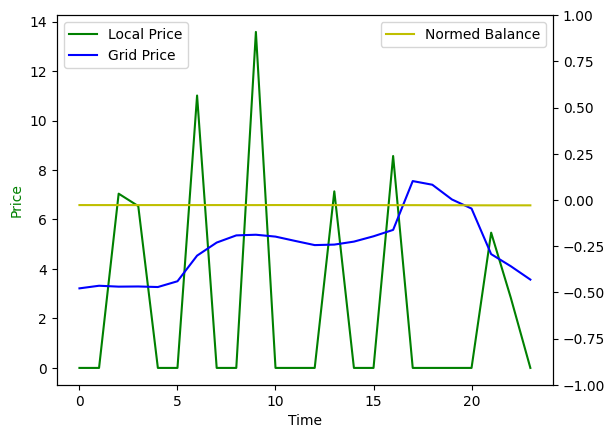

In [35]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_balanceonly/results.pkl"
outputfolder = "output/flex_balanceonly/"
dm = DataManager(prod_path='data/eval/pv.csv', demand_path='data/eval/demandprofiles.csv', cap_path='data/eval/caps.csv')
max_price = dm.get_all_max_price() + 2.0666
max_price = max_price * 1.5

with open(path, "rb") as file:
    results = cloudpickle.load(file)

results = list(results)

for rollout in results:

    aid = "CM"
    agent_actions = []
    budget_balance = []
    capacity_balance = []
    cap_limits = []
    total_import = []
    prices = []
    norm_balance = []
    grid_price = []
    rewards = []
    rewards += list(rollout.metrics["cm/rewards"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    agent_actions += list(rollout.actions_for_agent(aid))
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    budget_balance += list(rollout.metrics["cm/budget_balance"])
    capacity_balance += list(rollout.metrics["cm/capacity_balance"])
    cap_limits += list(rollout.metrics["cm/capacity_limit"])
    total_import += list(rollout.metrics["cm/total_import"])
    prices += list(rollout.metrics["env/current_price"])

    agent_actions = [action for action in agent_actions if action is not None]

    start = 48*30*11+48*24
    end = start + 48*1

    total_import = total_import[1:] + [0]

    rewards = rewards[start:end:2]
    agent_actions = agent_actions[start:end]
    capacity_balance = capacity_balance[start:end:2]
    cap_limits = cap_limits[start:end:2]
    total_import = total_import[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]

    # agent_actions = agent_actions[start:end]
    # capacity_balance = capacity_balance[start:end]
    # cap_limits = cap_limits[start:end]
    # total_import = total_import[start:end]
    prices = prices[start:end:2]
    budget_balance = budget_balance[start:end:2]
    #print(agent_actions)

    fig, ax1 = plt.subplots()

 

    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    #ax1.plot(agent_actions, 'k-', label="Agent Actions")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    #ax2.plot(rewards, 'r-', label="rewards")
    ax2.set_ylim(-1, 1)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


0.1406508085350786
0.1401556230061403


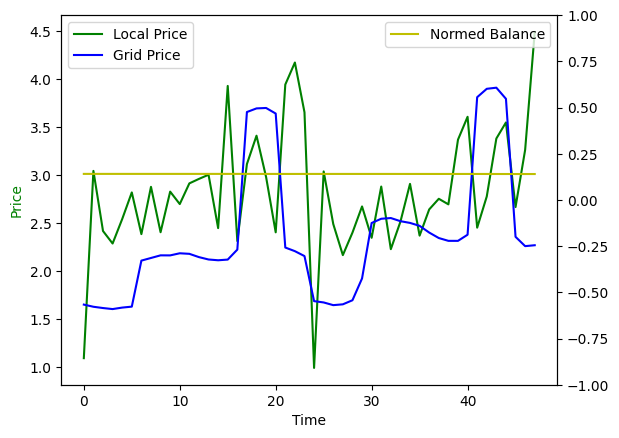

In [36]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_balanceonly_1/results.pkl"
outputfolder = "output/flex_balanceonly_1/"
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 48*30*8
    end = start + 48*2

    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    ax2.set_ylim(-1, 1)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()


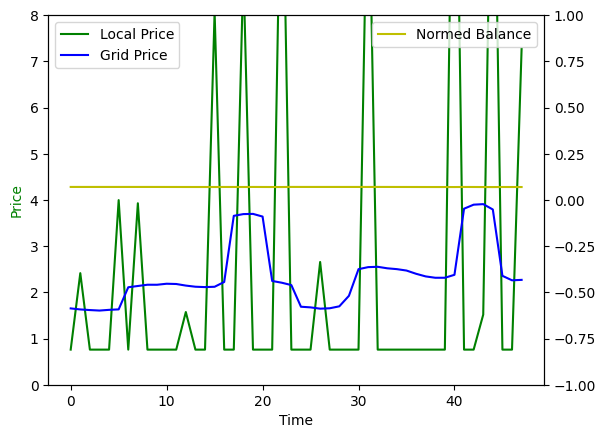

In [37]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_balanceonly_2/results.pkl"
outputfolder = "output/flex_balanceonly1/"
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 48*30*8
    end = start + 48*2

    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]
    budget_balance = budget_balance[start:end:2]

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    ax2.set_ylim(-1, 1)
    ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()


0.04148615924379365
-0.015030749492863392


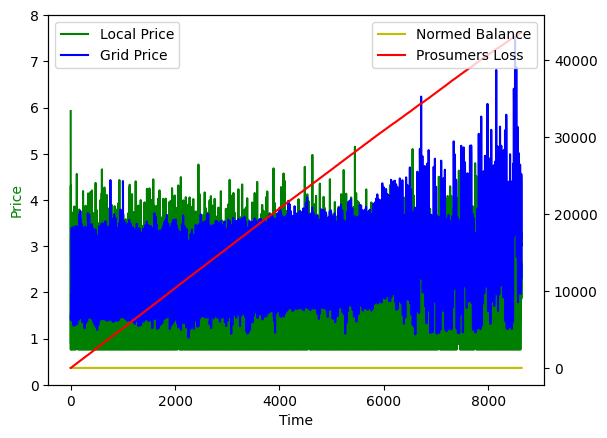

In [38]:
path = "output/flex_balanceonly_3/results.pkl"
outputfolder = "output/flex_balanceonly_3/"
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    prosumers_loss = []
    prosumers_loss += list(rollout.metrics["env/total_loss"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 0
    end = start + 48*30*12

    prosumers_loss = prosumers_loss[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    ax2.plot(prosumers_loss, 'r-', label="Prosumers Loss")
    #ax2.set_ylim(-1, 1)
    ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()


-0.09930780674094339
-0.1792271986059736


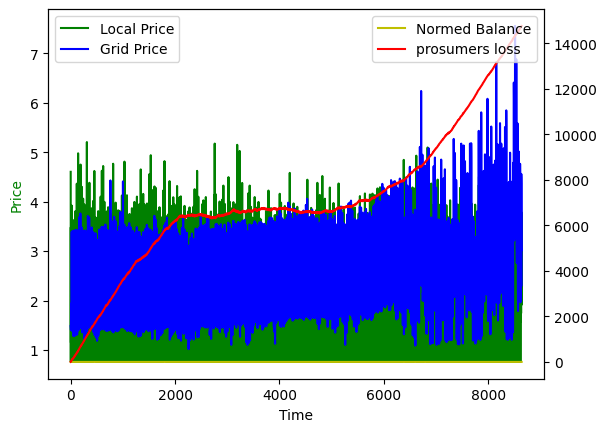

In [39]:

path = "output/flex_balanceonly_multi/results.pkl"
outputfolder = "output/flex_balanceonly_4/"
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    prosumers_loss = []
    prosumers_loss += list(rollout.metrics["env/total_loss"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 0
    end = start + 48*30*12

    prosumers_loss = prosumers_loss[start:end:2]
    #total_export = total_export[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    ax2.plot(prosumers_loss, 'r-', label="prosumers loss")
    #ax2.plot(total_export, 'k-', label="Total Export")
    #ax2.set_ylim(-1, 1)
    #ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

-0.1645055928584809
-0.07464158786110255


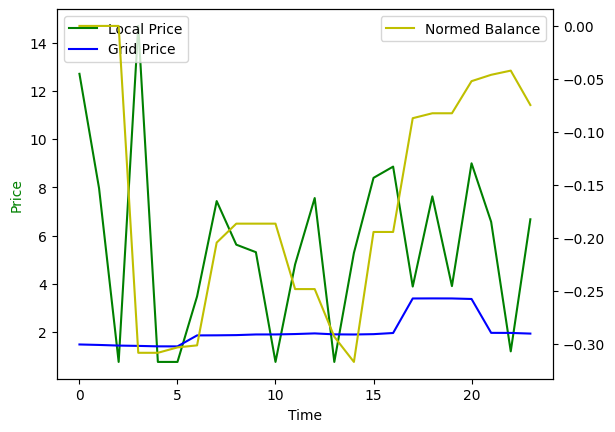

In [40]:

path = "output/flex_balance_twolevel/results.pkl"
outputfolder = "output/flex_balanceonly_4/"
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    #prosumers_loss = []
    prosumers_loss += list(rollout.metrics["env/total_loss"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 0
    end = start + 48*1

    #prosumers_loss = prosumers_loss[start:end:2]
    #total_export = total_export[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    #ax2.plot(prosumers_loss, 'r-', label="prosumers loss")
    #ax2.plot(total_export, 'k-', label="Total Export")
    #ax2.set_ylim(-1, 1)
    #ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

-0.02725703208005889
4.6529909604335655


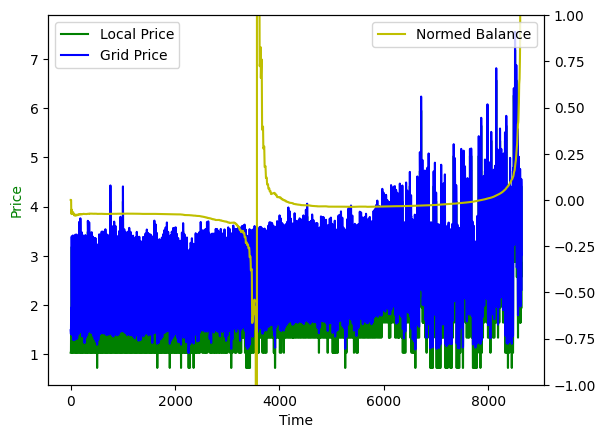

In [55]:

path = "output/flex_lstm/results.pkl"
outputfolder = "output/flex_lagrange/"
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    prosumers_loss = []
    mediator_loss = []
    prosumers_loss += list(rollout.metrics["env/total_loss"])
    mediator_loss += list(rollout.metrics["cm/mediator_netloss"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 0
    end = start + 48*30*12

    prosumers_loss = prosumers_loss[start:end:2]
    mediator_loss = mediator_loss[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    #ax2.plot(prosumers_loss, 'r-', label="prosumers loss")
    #ax2.plot(total_export, 'k-', label="Total Export")
    ax2.set_ylim(-1, 1)
    #ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

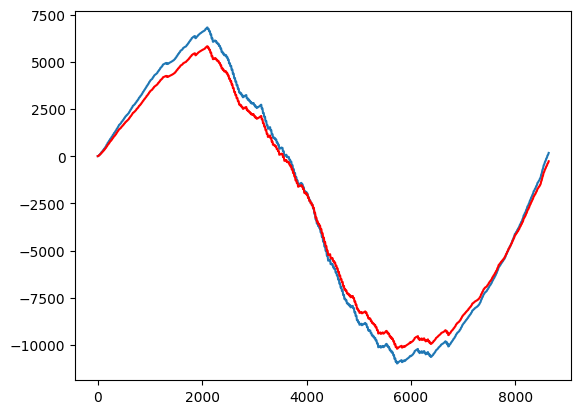

In [56]:
plt.plot(mediator_loss)
plt.plot(prosumers_loss, color='red')
plt.show()